## 1. Installation and imports

We start by importing all our libraries needed for this notebook. We also check the version of Python and PyTorch, and we initialize the device to be used (CPU or GPU).

In [15]:
# import statements for python, torch and companion libraries and your own modules
import torch
import os
import platform
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

from dotenv import load_dotenv
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score

load_dotenv()

# device initialization
device_name = os.getenv("DEVICE", "")
DEVICE = torch.device(
    device_name) if device_name else (
    torch.accelerator.current_accelerator()) if (
    torch.accelerator.is_available()) else (
    torch.device("cpu"))

print("Python :", platform.python_version())
print("PyTorch :", torch.__version__)
print("Device used :", DEVICE)

Python : 3.14.0
PyTorch : 2.14.1+cu132
Device used : cuda


Potentiel import supp à supprimer plus tard

In [13]:
import json, time, copy, platform, math
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models



## 2. Configuration

In this section, we will define the configuration parameters for our experiment. We start by defining the paths to the data and output directories. We also define some hyperparameters for training, such as the number of epochs, batch size, and learning rate. We also set a random seed for reproducibility and define a quick run option to limit the number of images processed for testing purposes.

In [3]:
# Defining global variables for data directories
DATA_ROOT = Path(os.getenv("DATA_ROOT", "/opt/iav/labs/data"))
DATA_ROOT = DATA_ROOT / "ms-coco"
IMAGE_DIR = DATA_ROOT / "images/train"
LABEL_DIR = DATA_ROOT / "labels/train"

# Defining global variables for output directories
OUTPUT_DIR = Path(os.getenv("JSON_PATH", "submission.json"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# TODO : check if all variables are defined
SEED = 30
EPOCHS = 10
BATCH_SIZE = 32
NUM_WORKERS = min(8, os.cpu_count() or 1)
IMAGE_SIZE = 224
PATIENCE = 3
VAL_FRACTION = 0.15  # Fraction of the dataset to be used for validation

TRANSFORM = False

# For a quick run, you can set QUICK_RUN to True and limit the number of images processed
QUICK_RUN = False
QUICK_MAX_IMAGES = 5000

# Pin memory for faster data transfer to GPU if using CUDA
PIN_MEMORY = DEVICE.type == "cuda"


# Function to set random seed for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = (DEVICE.type == "cuda")


set_seed()

print("Images :", IMAGE_DIR.resolve())
print("Annotations :", LABEL_DIR.resolve())
print("Outputs :", OUTPUT_DIR.resolve())

Images : C:\Users\theof\PycharmProjects\iav\data\ms-coco\images\train
Annotations : C:\Users\theof\PycharmProjects\iav\data\ms-coco\labels\train
Outputs : C:\Users\theof\PycharmProjects\iav\output\submission.json


## 3. Classes definitions and files verification

Here we define the classes and verify that we can access the images and annotations.

In [4]:
classes = (
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush"
)
NUM_CLASSES = len(classes)
assert NUM_CLASSES == 80, f"We expect to find 80 classes but {NUM_CLASSES} were found."

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset not found. Verify DATA_ROOT={DATA_ROOT.resolve()} ; "
        f"There must be a folder 'images/train' and a folder 'labels/train' containing the .jpg images and .cls annotation files respectively."
    )

test_images = sorted(IMAGE_DIR.glob("*.jpg"))
label_files = sorted(LABEL_DIR.glob("*.cls"))

if not test_images:
    raise RuntimeError("No .jpg files found in IMAGE_DIR.")
if not label_files:
    raise RuntimeError("No .cls files found in LABEL_DIR.")

print(f"Images : {len(test_images):,}")
print(f"Annotated files : {len(label_files):,}")
print("Image example :", test_images[0].name if test_images else None)
print("annotation example :", label_files[0].name if label_files else None)

if len(test_images) != len(label_files):
    # Warning if the number of images and labels do not match
    print(
        f"Warning: Number of images ({len(test_images)}) does not match number of labels ({len(label_files)}). Some images may not have corresponding labels or vice versa.")

Images : 65,000
Annotated files : 65,000
Image example : 000000000009.jpg
annotation example : 000000000009.cls


## 4. Annotations analysis

Before going straight to the training part, we will analyze the annotations to see the distribution of classes.

Annotations analysis:   0%|          | 0/65000 [00:00<?, ?it/s]

Images analysed : 65000
Annotations problematic : 0
Average number of classes/image : 2.926
Median : 2.0
Min :  1
Max :  18


,class,images_positives
78,hair drier,102
70,toaster,117
12,parking meter,396
21,bear,516
76,scissors,555
...,...,...
41,cup,5057
60,dining table,6546
2,car,6811
56,chair,7043


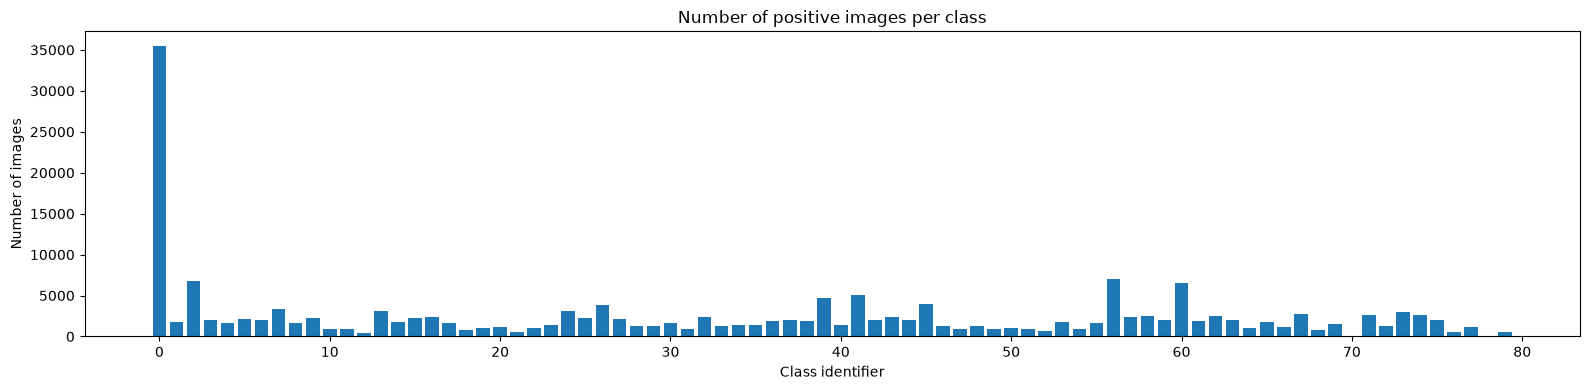

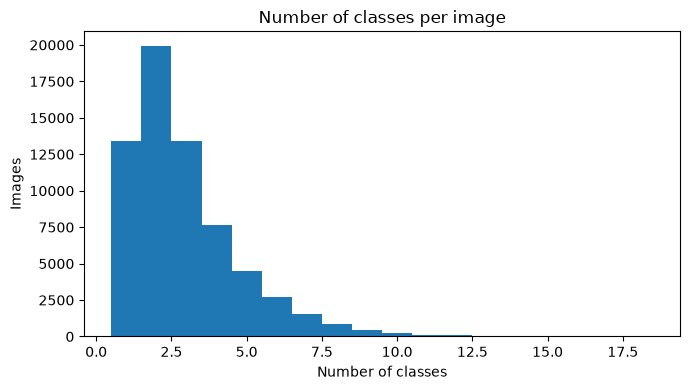

In [5]:
scan_files = label_files[:QUICK_MAX_IMAGES] if QUICK_RUN else label_files
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
labels_per_image = []
invalid_rows = []

for p in tqdm(scan_files, desc="Annotations analysis"):
    try:
        ids = [int(x.strip()) for x in p.read_text().splitlines() if x.strip()]
        if any(i < 0 or i >= NUM_CLASSES for i in ids):
            invalid_rows.append(p.name)
            continue
        class_counts[np.unique(ids)] += 1
        labels_per_image.append(len(set(ids)))
    except Exception as e:
        print(f"Error processing {p.name}: {e}")
        invalid_rows.append(p.name)

print("Images analysed :", len(scan_files))
print("Annotations problematic :", len(invalid_rows))
print("Average number of classes/image :", round(float(np.mean(labels_per_image)), 3))
print("Median :", float(np.median(labels_per_image)))
print("Min : ", min(labels_per_image))
print("Max : ", max(labels_per_image))

# Displaying the distribution of images per class in a DataFrame
freq_df = pd.DataFrame({"class": classes, "images_positives": class_counts})
display(freq_df.sort_values("images_positives"))

# Distribution of the number of images per class
plt.figure(figsize=(16, 4))
plt.bar(np.arange(NUM_CLASSES), class_counts)
plt.title("Number of positive images per class")
plt.xlabel("Class identifier")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

# Distribution of the number of classes per image
plt.figure(figsize=(7, 4))
plt.hist(labels_per_image, bins=range(1, max(labels_per_image) + 2), align="left")
plt.title("Number of classes per image")
plt.xlabel("Number of classes")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

## 5. Dataset PyTorch

In [6]:
class COCOTrainImageDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, annotations_dir, transform=None, maximum_images=None):
        self.annotations_dir = Path(annotations_dir)
        self.img_labels = sorted(self.annotations_dir.glob("*.cls"))
        if maximum_images is not None:
            self.img_labels = self.img_labels[:maximum_images]
        self.img_dir = Path(img_dir)
        self.transform = transform

        missing = [image.stem for image in self.img_labels if not (self.img_dir / f"{image.stem}.jpg").exists()]
        if missing:
            print(f"{len(missing)} Images not found ; examples : {missing[:5]}")

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, index):
        label_path = self.img_labels[index]
        image_path = self.img_dir / f"{label_path.stem}.jpg"
        image = Image.open(image_path).convert("RGB")
        with open(label_path, "r", encoding="utf-8") as f:
            labels = [int(label) for label in f.readlines()]
        if any(i < 0 or i >= NUM_CLASSES for i in labels):
            raise ValueError(f"Class identifier invalid : {label_path}")
        if self.transform:
            image = self.transform(image)
        labels = torch.zeros(80).scatter_(0, torch.tensor(labels), value=1)
        return image, labels


class COCOTestImageDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.image_files = sorted(self.img_dir.glob("*.jpg"))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        img_path = self.image_files[index]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path.stem

## 7. Transformations and DataLoaders
Here we define the transformations to be applied to the images if set, and we create the training and validation datasets and dataloaders.

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

max_images = QUICK_MAX_IMAGES if QUICK_RUN else None
base_dataset = COCOTrainImageDataset(IMAGE_DIR, LABEL_DIR, transform=None,
                                     maximum_images=max_images) if TRANSFORM else COCOTrainImageDataset(IMAGE_DIR,
                                                                                                        LABEL_DIR,
                                                                                                        transform=data_transform,
                                                                                                        maximum_images=max_images)
n_val = max(1, int(len(base_dataset) * VAL_FRACTION))
n_train = len(base_dataset) - n_val
generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = torch.utils.data.random_split(base_dataset, [n_train, n_val], generator=generator)


class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset, self.transform = subset, transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        original_idx = self.subset.indices[index]
        label_path = self.subset.dataset.label_files[original_idx]
        image = Image.open(self.subset.dataset.img_dir / f"{label_path.stem}.jpg").convert("RGB")
        labels = [int(x.strip()) for x in label_path.read_text().splitlines() if x.strip()]
        labels = torch.zeros(80).scatter_(0, torch.tensor(labels), value=1)
        return self.transform(image), labels


train_ds = TransformSubset(train_subset, train_transform) if TRANSFORM else train_subset
val_ds = TransformSubset(val_subset, val_transform) if TRANSFORM else val_subset

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                        persistent_workers=NUM_WORKERS > 0)

print(f"Train : {len(train_ds):,} | Validation : {len(val_ds):,}")

Train : 55,250 | Validation : 9,750


## 8. Metrics computation

In [9]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.uint8)
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def compute_class_metrics(class_prec, class_recall):
    class_results = []
    for p, r in zip(class_prec, class_recall):
        f1 = (0 if p == r == 0 else 2. / (1 / p + 1 / r))
        class_results.append({"f1": f1, "precision": p, "recall": r})
    return class_results


@torch.no_grad()
def predict_loader(model, loader, device=DEVICE):
    model.eval()
    probs_all, targets_all = [], []
    for images, targets in tqdm(loader, leave=False):
        logits = model(images.to(device, non_blocking=True))
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        targets_all.append(targets.numpy())
    return np.concatenate(targets_all), np.concatenate(probs_all)


def inverse_frequency_weighted_f1(y_true, y_pred):
    # Approximation explicite de la logique fournie dans le notebook de cours.
    positives = y_true.sum(axis=0)
    tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0)
    fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    recall = np.divide(tp, positives, out=np.zeros_like(tp, dtype=float), where=positives > 0)
    weights = np.divide(1.0, positives, out=np.zeros_like(positives, dtype=float), where=positives > 0)
    if weights.sum() == 0: return 0.0
    weights = weights / weights.sum()
    p, r = np.sum(precision * weights), np.sum(recall * weights)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)

## 9. Pretrained models and training functions

In [10]:
def build_model(backbone="resnet18", pretrained=True, freeze_backbone=False):
    if backbone == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
        if freeze_backbone:
            for name, p in model.named_parameters():
                if not name.startswith("fc."): p.requires_grad = False
    elif backbone == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
        if freeze_backbone:
            for name, p in model.named_parameters():
                if not name.startswith("fc."): p.requires_grad = False
    elif backbone == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
        if freeze_backbone:
            for name, p in model.named_parameters():
                if not name.startswith("classifier."): p.requires_grad = False
    else:
        raise ValueError(f"Backbone non pris en charge : {backbone}")
    return model.to(DEVICE)


def make_criterion(loss_name, train_targets=None):
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss()
    if loss_name == "weighted_bce":
        if train_targets is None: raise ValueError("train_targets requis pour weighted_bce")
        pos = train_targets.sum(axis=0)
        neg = len(train_targets) - pos
        pos_weight = torch.tensor(neg / np.maximum(pos, 1), dtype=torch.float32, device=DEVICE)
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    raise ValueError("Pour la Focal Loss, ajouter/valider une implémentation dédiée avant comparaison.")

## 10.Training loop and evaluation

In [11]:
def fit_experiment(name, backbone="resnet18", pretrained=True, freeze_backbone=False, loss_name="bce", lr=1e-4,
                   epochs=EPOCHS):
    model = build_model(backbone, pretrained, freeze_backbone)
    # Calcul des cibles train pour la loss pondérée, si sélectionnée.
    train_targets = []
    for _, y in DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0):
        train_targets.append(y.numpy())
    train_targets = np.concatenate(train_targets)
    criterion = make_criterion(loss_name, train_targets)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.5)
    best_loss, best_state, stale = float("inf"), None, 0
    history = []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running, seen = 0.0, 0
        for images, targets in tqdm(train_loader, desc=f"{name} — époque {epoch + 1}/{epochs}", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0)
            seen += images.size(0)

        y_val, p_val = predict_loader(model, val_loader)
        val_loss = float(np.mean([
            criterion(model(images.to(DEVICE)), targets.to(DEVICE)).item()
            for images, targets in []  # loss calculée proprement ci-dessous
        ])) if False else None
        # Évaluation de la loss de validation par batch.
        model.eval()
        total_loss, total_n = 0.0, 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                batch_loss = criterion(model(images), targets)
                total_loss += batch_loss.item() * images.size(0)
                total_n += images.size(0)
        val_loss = total_loss / max(total_n, 1)
        metrics = compute_metrics(y_val, p_val, threshold=0.5)
        scheduler.step(val_loss)
        row = {"experiment": name, "epoch": epoch + 1, "train_loss": running / max(seen, 1),
               "val_loss": val_loss, **metrics, "lr": optimizer.param_groups[0]["lr"]}
        history.append(row)
        print({k: round(v, 4) if isinstance(v, (float, np.floating)) else v for k, v in row.items()})
        if val_loss < best_loss:
            best_loss, stale = val_loss, 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({"model_state_dict": best_state, "backbone": backbone,
                        "pretrained": pretrained, "freeze_backbone": freeze_backbone,
                        "loss_name": loss_name, "threshold": 0.5, "classes": list(classes)},
                       OUTPUT_DIR / f"{name}_best.pt")
        else:
            stale += 1
            if stale >= PATIENCE:
                print("Arrêt anticipé : la loss de validation ne s'améliore plus.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    y_val, p_val = predict_loader(model, val_loader)
    summary = {"experiment": name, "backbone": backbone, "pretrained": pretrained,
               "freeze_backbone": freeze_backbone, "loss": loss_name, "lr": lr,
               "epochs_run": len(history), "best_val_loss": best_loss,
               **compute_metrics(y_val, p_val, 0.5),
               "inverse_frequency_weighted_f1": inverse_frequency_weighted_f1(y_val, (p_val >= 0.5).astype(np.uint8)),
               "seconds": time.time() - start}
    return model, pd.DataFrame(history), summary, y_val, p_val

In [ ]:
def train_loop(train_loader, net, criterion, optimizer, device, mbatch_loss_group=-1):
    net.train()
    running_loss = 0.0
    mbatch_losses = []
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        # following condition False by default, unless mbatch_loss_group > 0
        if i % mbatch_loss_group == mbatch_loss_group - 1:
            mbatch_losses.append(running_loss / mbatch_loss_group)
            running_loss = 0.0
    if mbatch_loss_group > 0:
        return mbatch_losses


def validation_loop(val_loader, net, criterion, num_classes, device, multi_label=False, th_multi_label=0.5,
                    one_hot=False, class_metrics=False):
    net.eval()
    loss = 0
    correct = 0
    size = len(val_loader.dataset)
    class_total = {label: 0 for label in range(num_classes)}
    class_tp = {label: 0 for label in range(num_classes)}
    class_fp = {label: 0 for label in range(num_classes)}
    with torch.no_grad():
        for data in val_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss += criterion(outputs, labels).item() * images.size(0)
            if not multi_label:
                predictions = torch.zeros_like(outputs)
                predictions[torch.arange(outputs.shape[0]), torch.argmax(outputs, dim=1)] = 1.0
            else:
                predictions = torch.where(outputs > th_multi_label, 1.0, 0.0)
            if not one_hot:
                labels_mat = torch.zeros_like(outputs)
                labels_mat[torch.arange(outputs.shape[0]), labels] = 1.0
                labels = labels_mat

            tps = predictions * labels
            fps = predictions - tps

            tps = tps.sum(dim=0)
            fps = fps.sum(dim=0)
            lbls = labels.sum(dim=0)

            for c in range(num_classes):
                class_tp[c] += tps[c]
                class_fp[c] += fps[c]
                class_total[c] += lbls[c]

            correct += tps.sum()

    class_prec = []
    class_recall = []
    freqs = []
    for c in range(num_classes):
        class_prec.append(0 if class_tp[c] == 0 else
                          class_tp[c] / (class_tp[c] + class_fp[c]))
        class_recall.append(0 if class_tp[c] == 0 else
                            class_tp[c] / class_total[c])
        freqs.append(class_total[c])

    freqs = torch.tensor(freqs)
    class_weights = 1. / freqs
    class_weights /= class_weights.sum()
    class_prec = torch.tensor(class_prec)
    class_recall = torch.tensor(class_recall)
    prec = (class_prec * class_weights).sum()
    recall = (class_recall * class_weights).sum()
    f1 = 2. / (1 / prec + 1 / recall)
    val_loss = loss / size
    accuracy = correct / freqs.sum()
    results = {"loss": val_loss, "accuracy": accuracy, "f1": f1, "precision": prec, "recall": recall}

    if class_metrics:
        results = results, compute_class_metrics(class_prec, class_recall)

    return results

## 11. Experiments

In [ ]:
EXPERIMENTS = [
    {"name": "resnet18_bce", "backbone": "resnet18", "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},
    {"name": "resnet18_frozen", "backbone": "resnet18", "freeze_backbone": True, "loss_name": "bce", "lr": 5e-4},
    {"name": "resnet50_bce", "backbone": "resnet50", "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},
    {"name": "efficientnet_b0_bce", "backbone": "efficientnet_b0", "freeze_backbone": False, "loss_name": "bce",
     "lr": 1e-4},
    {"name": "resnet18_weighted_bce", "backbone": "resnet18", "freeze_backbone": False, "loss_name": "weighted_bce",
     "lr": 1e-4},
]

# Pour un premier test du pipeline, décommenter :
EXPERIMENTS = EXPERIMENTS[:1]

experiment_results = []
histories = {}
prediction_cache = {}
models_cache = {}

for cfg in EXPERIMENTS:
    model, hist, summary, y_val, p_val = fit_experiment(**cfg, epochs=EPOCHS)
    experiment_results.append(summary)
    histories[cfg["name"]] = hist
    prediction_cache[cfg["name"]] = (y_val, p_val)
    models_cache[cfg["name"]] = model
    pd.DataFrame(experiment_results).to_csv(OUTPUT_DIR / "experiment_results_partial.csv", index=False)

results_df = pd.DataFrame(experiment_results).sort_values("f1_macro", ascending=False)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "experiment_results.csv", index=False)

In [ ]:
# creation of tensorboard SummaryWriter (optional)

# epochs loop:
#   train
#   validate on train set
#   validate on validation set
#   update graphs (optional)
#   is new model better than current model ?
#       save it, update current best metric

# close tensorboard SummaryWriter if created (optional)

In [ ]:
def update_graphs(summary_writer, epoch, train_results, test_results,
                  train_class_results=None, test_class_results=None,
                  class_names=None, mbatch_group=-1, mbatch_count=0, mbatch_losses=None):
    if mbatch_group > 0:
        for i in range(len(mbatch_losses)):
            summary_writer.add_scalar("Losses/Train mini-batches",
                                      mbatch_losses[i],
                                      epoch * mbatch_count + (i + 1) * mbatch_group)

    summary_writer.add_scalars("Losses/Train Loss vs Test Loss",
                               {"Train Loss": train_results["loss"],
                                "Test Loss": test_results["loss"]},
                               (epoch + 1) if not mbatch_group > 0
                               else (epoch + 1) * mbatch_count)

    summary_writer.add_scalars("Metrics/Train Accuracy vs Test Accuracy",
                               {"Train Accuracy": train_results["accuracy"],
                                "Test Accuracy": test_results["accuracy"]},
                               (epoch + 1) if not mbatch_group > 0
                               else (epoch + 1) * mbatch_count)

    summary_writer.add_scalars("Metrics/Train F1 vs Test F1",
                               {"Train F1": train_results["f1"],
                                "Test F1": test_results["f1"]},
                               (epoch + 1) if not mbatch_group > 0
                               else (epoch + 1) * mbatch_count)

    summary_writer.add_scalars("Metrics/Train Precision vs Test Precision",
                               {"Train Precision": train_results["precision"],
                                "Test Precision": test_results["precision"]},
                               (epoch + 1) if not mbatch_group > 0
                               else (epoch + 1) * mbatch_count)

    summary_writer.add_scalars("Metrics/Train Recall vs Test Recall",
                               {"Train Recall": train_results["recall"],
                                "Test Recall": test_results["recall"]},
                               (epoch + 1) if not mbatch_group > 0
                               else (epoch + 1) * mbatch_count)

    if train_class_results and test_class_results:
        for i in range(len(train_class_results)):
            summary_writer.add_scalars(f"Class Metrics/{class_names[i]}/Train F1 vs Test F1",
                                       {"Train F1": train_class_results[i]["f1"],
                                        "Test F1": test_class_results[i]["f1"]},
                                       (epoch + 1) if not mbatch_group > 0
                                       else (epoch + 1) * mbatch_count)

            summary_writer.add_scalars(f"Class Metrics/{class_names[i]}/Train Precision vs Test Precision",
                                       {"Train Precision": train_class_results[i]["precision"],
                                        "Test Precision": test_class_results[i]["precision"]},
                                       (epoch + 1) if not mbatch_group > 0
                                       else (epoch + 1) * mbatch_count)

            summary_writer.add_scalars(f"Class Metrics/{class_names[i]}/Train Recall vs Test Recall",
                                       {"Train Recall": train_class_results[i]["recall"],
                                        "Test Recall": test_class_results[i]["recall"]},
                                       (epoch + 1) if not mbatch_group > 0
                                       else (epoch + 1) * mbatch_count)
    summary_writer.flush()

In [ ]:
# global variables defining training hyper-parameters among other things
LEARNING_RATE = 0.001
THRESHOLD = 0.5
